In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance

In [4]:
import pandas as pd

file_paths = [
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv'
]

df_list = [pd.read_csv(file) for file in file_paths]
df = pd.concat(df_list, ignore_index=True)

df.to_csv('combined_dataset.csv', index=False)


In [5]:
df = pd.read_csv('combined_dataset.csv')


In [6]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830742,53,94939,4,2,188,226,47,47,47.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [9]:
print(df[' Label'].value_counts())


BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name:  Label, dtype: int64


In [10]:
# Z-score normalization
features = df.dtypes[df.dtypes != 'object'].index
df[features] = df[features].apply(
    lambda x: (x - x.mean()) / (x.std()))
# Fill empty values with 0
df = df.fillna(0)

In [11]:
labelencoder = LabelEncoder()
df.iloc[:, -1] = labelencoder.fit_transform(df.iloc[:, -1])

In [12]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())


['destination port', 'flow duration', 'total fwd packets', 'total backward packets', 'total length of fwd packets', 'total length of bwd packets', 'fwd packet length max', 'fwd packet length min', 'fwd packet length mean', 'fwd packet length std', 'bwd packet length max', 'bwd packet length min', 'bwd packet length mean', 'bwd packet length std', 'flow bytes/s', 'flow packets/s', 'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min', 'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max', 'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std', 'bwd iat max', 'bwd iat min', 'fwd psh flags', 'bwd psh flags', 'fwd urg flags', 'bwd urg flags', 'fwd header length', 'bwd header length', 'fwd packets/s', 'bwd packets/s', 'min packet length', 'max packet length', 'packet length mean', 'packet length std', 'packet length variance', 'fin flag count', 'syn flag count', 'rst flag count', 'psh flag count', 'ack flag count', 'urg flag count', 'cwe flag count', 'ece flag count

In [13]:
print(df['label'].value_counts())


0     2273097
4      231073
10     158930
2      128027
3       10293
7        7938
11       5897
6        5796
5        5499
1        1966
12       1507
14        652
9          36
13         21
8          11
Name: label, dtype: int64


In [14]:
df_minor = df[(df['label']==6)|(df['label']==1)|(df['label']==4)]
df_major = df.drop(df_minor.index)

In [15]:
X = df_major.drop(['label'],axis=1)
y = df_major.iloc[:, -1].values.reshape(-1,1)
y=np.ravel(y)

In [16]:
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(n_clusters=1000, random_state=0).fit(X)

In [17]:
klabel=kmeans.labels_
df_major['klabel']=klabel

In [18]:
df_major['klabel'].value_counts()

689    16243
674    12881
28     11793
708    10525
668    10516
       ...  
92        42
869       42
97        38
331       34
98        21
Name: klabel, Length: 998, dtype: int64

In [19]:
cols = list(df_major)
cols.insert(78, cols.pop(cols.index('label')))
df_major = df_major.loc[:, cols]

In [20]:
df_major

,destination port,flow duration,total fwd packets,total backward packets,total length of fwd packets,total length of bwd packets,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min,label,klabel
0,2.559312,-0.439347,-0.009819,-0.010421,-0.053765,-0.007142,-0.281099,-0.210703,-0.280518,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,885
1,2.569649,-0.439344,-0.011153,-0.009418,-0.054365,-0.007139,-0.281099,-0.210703,-0.280518,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,376
2,2.569704,-0.439345,-0.011153,-0.009418,-0.054365,-0.007139,-0.281099,-0.210703,-0.280518,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,376
3,2.087360,-0.439346,-0.011153,-0.009418,-0.054365,-0.007139,-0.281099,-0.210703,-0.280518,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,880
4,2.559203,-0.439347,-0.009819,-0.010421,-0.053765,-0.007142,-0.281099,-0.210703,-0.280518,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,-0.438561,-0.438390,-0.007151,-0.008416,-0.043758,-0.007075,-0.250424,0.153902,-0.162296,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,700
2830739,-0.438561,-0.439337,-0.009819,-0.008416,-0.046560,-0.006982,-0.230903,0.385923,-0.087065,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,192
2830740,2.732418,-0.439344,-0.009819,-0.009418,-0.051863,-0.007139,-0.246240,-0.310140,-0.229468,-0.167112,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,312
2830741,-0.438561,-0.408187,-0.004484,-0.008416,-0.035753,-0.007029,-0.244846,0.220194,-0.140802,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,224


In [21]:
def typicalSampling(group):
    name = group.name
    frac = 0.008
    return group.sample(frac=frac)

result = df_major.groupby(
    'klabel', group_keys=False
).apply(typicalSampling)

In [22]:
result['label'].value_counts()

0     18180
10     1262
2      1015
3        84
7        67
5        55
11       44
12       13
14        8
Name: label, dtype: int64

In [23]:
result

,destination port,flow duration,total fwd packets,total backward packets,total length of fwd packets,total length of bwd packets,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min,label,klabel
2085265,-0.438561,-0.439342,-0.009819,-0.008416,-0.046760,-0.007038,-0.232297,0.369350,-0.092438,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,0
1064019,-0.438561,-0.439341,-0.009819,-0.008416,-0.046360,-0.007041,-0.229508,0.402496,-0.081691,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,0
2800195,-0.438561,-0.439339,-0.009819,-0.008416,-0.046360,-0.007044,-0.229508,0.402496,-0.081691,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,0
2074135,-0.438561,-0.439340,-0.009819,-0.008416,-0.046560,-0.007041,-0.230903,0.385923,-0.087065,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,0
1949933,-0.438561,-0.439339,-0.009819,-0.008416,-0.046360,-0.007041,-0.229508,0.402496,-0.081691,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2724159,-0.438561,-0.430694,-0.009819,-0.008416,-0.047761,-0.007036,-0.239269,0.286485,-0.119307,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,999
1618985,-0.438561,-0.436561,-0.009819,-0.008416,-0.047561,-0.007036,-0.237874,0.303058,-0.113933,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,999
1983462,-0.438561,-0.434570,-0.009819,-0.008416,-0.047761,-0.007039,-0.239269,0.286485,-0.119307,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,999
1983663,-0.438561,-0.438644,-0.009819,-0.008416,-0.047961,-0.007034,-0.240663,0.269913,-0.124681,-0.245069,...,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0,999


In [24]:
result = result.reset_index(drop=True)

X = result.drop(['label'], axis=1).values

y = result['label'].apply(lambda x: 0 if x == 0 else 1).values.reshape(-1, 1).ravel()

print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0, stratify=y)

print("Split successful!")

0    18180
1     2548
dtype: int64
Split successful!


In [25]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16582, 79)
X_test shape: (4146, 79)
y_train shape: (16582,)
y_test shape: (4146,)


In [26]:
print(df['label'].dtype)
print(pd.Series(y).unique())

int64
[0 1]


In [27]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif

df = result.reset_index(drop=True)

X = df.drop(['label'], axis=1).values
y = df['label'].astype(int).values

importances = mutual_info_classif(X, y)

features = df.drop(['label'], axis=1).columns
importances = mutual_info_classif(X, y)

f_list = sorted(zip(map(lambda x: round(x, 4), importances), features), reverse=True)

print("Feature importances by mutual information (information gain):")
for importance, feature in f_list:
    print(f"{feature}: {importance}")

total_importance = sum(importances)

f_list2 = sorted(zip(importances / total_importance, features), reverse=True)

accumulated_importance = 0
selected_features = []

for importance, feature in f_list2:
    accumulated_importance += importance
    selected_features.append(feature)
    if accumulated_importance >= 0.9:
        break

print(f"\nSelected top features (covering 90% of total importance): {len(selected_features)} features")
print(selected_features)

X_fs = df[selected_features].values
print("\nShape after feature selection:", X_fs.shape)


Feature importances by mutual information (information gain):
klabel: 0.4501
average packet size: 0.401
packet length std: 0.3694
packet length variance: 0.3685
packet length mean: 0.3683
total length of fwd packets: 0.3599
subflow fwd bytes: 0.3577
total length of bwd packets: 0.3189
subflow bwd bytes: 0.3183
bwd packet length mean: 0.3028
avg bwd segment size: 0.3019
init_win_bytes_backward: 0.2947
fwd packet length max: 0.2936
destination port: 0.2928
bwd packet length max: 0.2896
fwd header length.1: 0.2885
avg fwd segment size: 0.2875
fwd packet length mean: 0.286
fwd header length: 0.2858
max packet length: 0.2741
init_win_bytes_forward: 0.2702
bwd header length: 0.24
flow iat max: 0.2354
flow duration: 0.2308
fwd iat max: 0.2231
fwd iat total: 0.2214
fwd packets/s: 0.2199
bwd packets/s: 0.2187
fwd iat mean: 0.2033
flow iat mean: 0.2006
min_seg_size_forward: 0.1989
total fwd packets: 0.1857
subflow fwd packets: 0.1845
bwd packet length min: 0.1766
total backward packets: 0.1732
s

In [28]:
import urllib.request

url = "https://raw.githubusercontent.com/SantiagoEG/FCBF_module/master/FCBF_module.py"
urllib.request.urlretrieve(url, "FCBF_module.py")


('FCBF_module.py', <http.client.HTTPMessage at 0x145429f10>)

In [29]:
from FCBF_module import FCBF, FCBFK, FCBFiP, get_i
fcbf = FCBFK(k = 20)

In [30]:
X_fss = fcbf.fit_transform(X_fs,y)

In [31]:
X_fss.shape

(20728, 20)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_fss,y, train_size = 0.8, test_size = 0.2, random_state = 0)

In [33]:
X_train.shape

(16582, 20)

In [34]:
pd.Series(y_train).value_counts()

0     14545
10     1008
2       815
3        66
7        53
5        42
11       37
12       10
14        6
dtype: int64

In [35]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy={2: 1000})
X_train, y_train = smote.fit_resample(X_train, y_train)
print(pd.Series(y_train).value_counts())


0     14545
10     1008
2      1000
3        66
7        53
5        42
11       37
12       10
14        6
dtype: int64


Accuracy of XGBoost: 0.992040520984081
Precision of XGBoost: 0.9907973375497934
Recall of XGBoost: 0.992040520984081
F1-score of XGBoost: 0.990687385747672
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       1.00      0.83      0.91        18
           3       0.82      0.69      0.75        13
           4       1.00      0.64      0.78        14
           5       0.98      0.99      0.98       254
           6       1.00      0.14      0.25         7
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.75      0.59      0.63      4146
weighted avg       0.99      0.99      0.99      4146



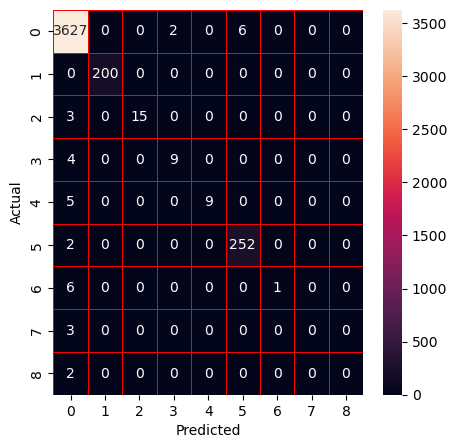

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
import numpy as np

train_classes = np.unique(y_train_encoded)
mask = np.isin(y_test_encoded, train_classes)

X_test_filtered = X_test[mask]
y_test_filtered = y_test_encoded[mask]

import xgboost as xgb
xg = xgb.XGBClassifier(n_estimators=10, use_label_encoder=False, eval_metric='mlogloss')
xg.fit(X_train, y_train_encoded)

y_predict = xg.predict(X_test_filtered)

from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = xg.score(X_test_filtered, y_test_filtered)
print('Accuracy of XGBoost:', accuracy)

precision, recall, fscore, _ = precision_recall_fscore_support(y_test_filtered, y_predict, average='weighted')
print('Precision of XGBoost:', precision)
print('Recall of XGBoost:', recall)
print('F1-score of XGBoost:', fscore)

print(classification_report(y_test_filtered, y_predict))

cm = confusion_matrix(y_test_filtered, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [37]:
!pip install hyperopt
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.metrics import accuracy_score
import xgboost as xgb

def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': abs(float(params['learning_rate'])),
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
    }

    clf = xgb.XGBClassifier(**params)

    clf.fit(X_train, y_train_encoded)

    y_pred = clf.predict(X_test_filtered)

    score = accuracy_score(y_test_filtered, y_pred)
    return {'loss': -score, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 10, 100, 5),
    'max_depth': hp.quniform('max_depth', 4, 100, 1),
    'learning_rate': hp.normal('learning_rate', 0.01, 0.9),
}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)  
)

print("XGBoost: Hyperopt estimated optimum {}".format(best))

100%|████████| 20/20 [00:06<00:00,  2.92trial/s, best loss: -0.9944524843222383]
XGBoost: Hyperopt estimated optimum {'learning_rate': 1.3936961138416604, 'max_depth': 74.0, 'n_estimators': 35.0}


Accuracy of XGBoost: 0.9937288953207911
Precision of XGBoost: 0.993956611314888
Recall of XGBoost: 0.9937288953207911
F1-score of XGBoost: 0.9937034767294433
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       0.89      0.89      0.89        18
           3       0.85      0.85      0.85        13
           4       1.00      0.71      0.83        14
           5       0.98      0.99      0.98       254
           6       1.00      1.00      1.00         7
           7       0.29      0.67      0.40         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.78      0.79      0.77      4146
weighted avg       0.99      0.99      0.99      4146



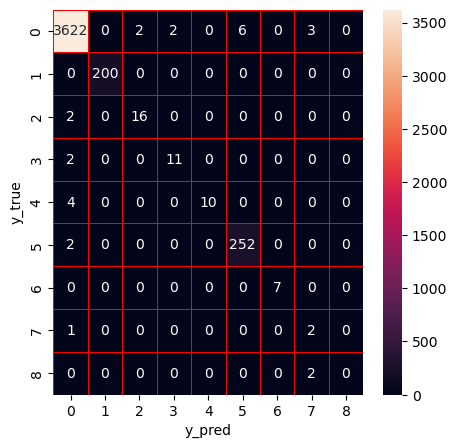

In [38]:
xg = xgb.XGBClassifier(learning_rate= 0.7340229699980686, n_estimators = 70, max_depth = 14)
xg.fit(X_train,y_train_encoded)

y_predict = xg.predict(X_test_filtered)
y_true = y_test_filtered

xg_score=xg.score(X_test_filtered, y_test_filtered)
print('Accuracy of XGBoost: '+ str(xg_score))

precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))

cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [39]:
xg_train = xg.predict(X_train)
xg_test = xg.predict(X_test_filtered)

print("Training Accuracy (xgboost):", accuracy_score(y_train_encoded, xg_train))
print("Testing Accuracy (xgboost):", accuracy_score(y_test_filtered, xg_test))



Training Accuracy (xgboost): 0.9976740025049203
Testing Accuracy (xgboost): 0.9937288953207911


Accuracy of RF: 0.9937288953207911
Precision of RF: 0.993254843631783
Recall of RF: 0.9937288953207911
F1-score of RF: 0.9934452104661343

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       0.89      0.89      0.89        18
           3       0.79      0.85      0.81        13
           4       0.91      0.71      0.80        14
           5       0.98      0.99      0.98       254
           6       1.00      1.00      1.00         7
           7       0.33      0.33      0.33         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.77      0.75      0.76      4146
weighted avg       0.99      0.99      0.99      4146



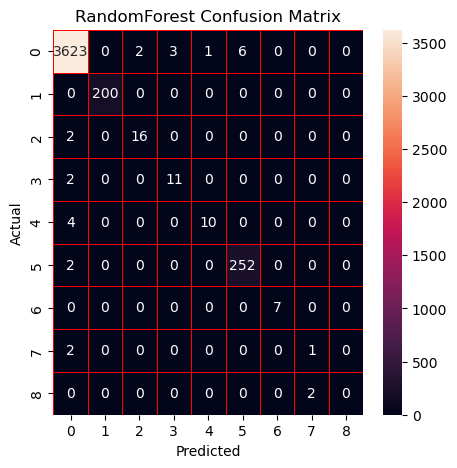

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train_encoded)

y_predict = rf.predict(X_test_filtered)
y_true = y_test_filtered

rf_score = rf.score(X_test_filtered, y_test_filtered)
print('Accuracy of RF:', rf_score)

precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of RF:', precision)
print('Recall of RF:', recall)
print('F1-score of RF:', fscore)

print("\nClassification Report:\n", classification_report(y_true, y_predict))

cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RandomForest Confusion Matrix")
plt.show()


In [41]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'criterion': params['criterion']
    }

    clf = RandomForestClassifier(**params, random_state=0)
    clf.fit(X_train, y_train_encoded)

    y_pred = clf.predict(X_test_filtered)
    score = accuracy_score(y_test_filtered, y_pred)

    return {'loss': -score, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 10, 200, 1),
    'max_depth': hp.quniform('max_depth', 5, 50, 1),
    'max_features': hp.quniform('max_features', 1, X_train.shape[1], 1),  
    'min_samples_split': hp.quniform('min_samples_split', 2, 11, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 11, 1),
    'criterion': hp.choice('criterion', ['gini', 'entropy'])
}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42) 
)

print("Random Forest: Hyperopt estimated optimum {}".format(best))


100%|████████| 20/20 [00:56<00:00,  2.81s/trial, best loss: -0.9939700916546068]
Random Forest: Hyperopt estimated optimum {'criterion': 1, 'max_depth': 10.0, 'max_features': 20.0, 'min_samples_leaf': 1.0, 'min_samples_split': 10.0, 'n_estimators': 54.0}


Accuracy of RF: 0.9934876989869754
Precision of RF: 0.9932181893847093
Recall of RF: 0.9934876989869754
F1-score of RF: 0.9932583537215922

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       0.89      0.89      0.89        18
           3       0.67      0.92      0.77        13
           4       0.83      0.71      0.77        14
           5       0.98      0.99      0.99       254
           6       1.00      1.00      1.00         7
           7       0.50      0.33      0.40         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.76      0.76      0.76      4146
weighted avg       0.99      0.99      0.99      4146



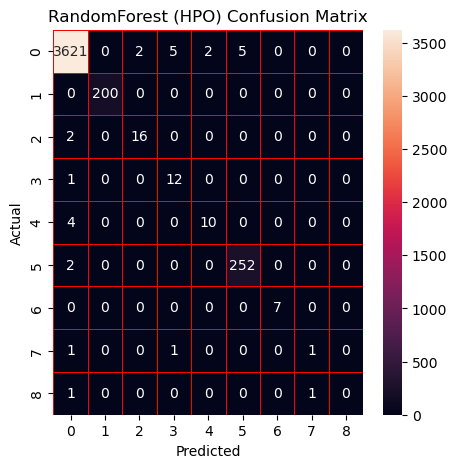

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_hpo = RandomForestClassifier(
    n_estimators=71,
    min_samples_leaf=1,
    max_depth=46,
    min_samples_split=9,
    max_features=20,
    criterion='entropy',
    random_state=0
)

rf_hpo.fit(X_train, y_train_encoded)

y_predict = rf_hpo.predict(X_test_filtered)
y_true = y_test_filtered

from sklearn.metrics import accuracy_score

rf_score = accuracy_score(y_true, y_predict)
print('Accuracy of RF:', rf_score)

precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of RF:', precision)
print('Recall of RF:', recall)
print('F1-score of RF:', fscore)

print("\nClassification Report:\n", classification_report(y_true, y_predict))

cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RandomForest (HPO) Confusion Matrix")
plt.show()


In [43]:
rf_train = rf_hpo.predict(X_train)
rf_test = rf_hpo.predict(X_test_filtered)

print("Training Accuracy (rf):", accuracy_score(y_train_encoded, rf_train))
print("Testing Accuracy (rf):", accuracy_score(y_test_filtered, rf_test))

Training Accuracy (rf): 0.9968390290451482
Testing Accuracy (rf): 0.9934876989869754


Accuracy of Decision Tree: 0.9930053063193439
Precision of Decision Tree: 0.9929249352827837
Recall of Decision Tree: 0.9930053063193439
F1-score of Decision Tree: 0.9929042158955302

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       0.89      0.89      0.89        18
           3       0.79      0.85      0.81        13
           4       0.91      0.71      0.80        14
           5       0.97      0.99      0.98       254
           6       1.00      1.00      1.00         7
           7       0.20      0.33      0.25         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.75      0.75      0.75      4146
weighted avg       0.99      0.99      0.99      4146



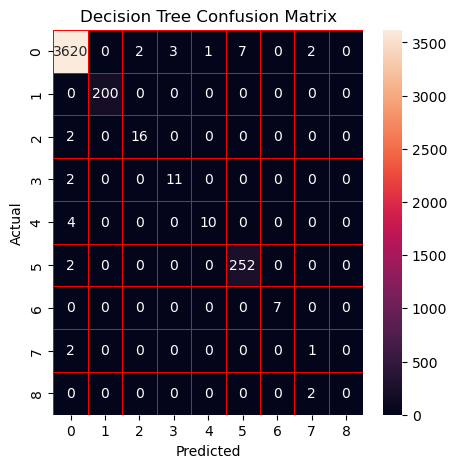

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train_encoded)

y_predict = dt.predict(X_test_filtered)
y_true = y_test_filtered

from sklearn.metrics import accuracy_score

dt_score = accuracy_score(y_true, y_predict)
print('Accuracy of Decision Tree:', dt_score)

precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Decision Tree:', precision)
print('Recall of Decision Tree:', recall)
print('F1-score of Decision Tree:', fscore)

print("\nClassification Report:\n", classification_report(y_true, y_predict))

cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()


In [45]:
dt_train = dt.predict(X_train)
dt_test = dt.predict(X_test_filtered)

print("Training Accuracy (Decision Tree):", accuracy_score(y_train_encoded, dt_train))
print("Testing Accuracy (Decision Tree):", accuracy_score(y_test_filtered, dt_test))


Training Accuracy (Decision Tree): 0.9983300530804556
Testing Accuracy (Decision Tree): 0.9930053063193439


In [46]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold

def objective(params):
    params = {
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        "min_samples_split":int(params['min_samples_split']),
        "min_samples_leaf":int(params['min_samples_leaf']),
        "criterion":str(params['criterion'])
    }
    clf = DecisionTreeClassifier( **params)
    clf.fit(X_train,y_train)
    score=clf.score(X_test,y_test)

    return {'loss':-score, 'status': STATUS_OK }

space = {
    'max_depth': hp.quniform('max_depth', 5, 50, 1),
    "max_features":hp.quniform('max_features', 1, 20, 1),
    "min_samples_split":hp.quniform('min_samples_split',2,11,1),
    "min_samples_leaf":hp.quniform('min_samples_leaf',1,11,1),
    "criterion":hp.choice('criterion',['gini','entropy'])
}

best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=50)
print("Decision tree: Hyperopt estimated optimum {}".format(best))

100%|████████| 50/50 [00:02<00:00, 20.30trial/s, best loss: -0.9937288953207911]
Decision tree: Hyperopt estimated optimum {'criterion': 0, 'max_depth': 28.0, 'max_features': 9.0, 'min_samples_leaf': 1.0, 'min_samples_split': 2.0}


Accuracy of Decision Tree (HPO): 0.9925229136517125
Precision of Decision Tree (HPO): 0.9922629522109119
Recall of Decision Tree (HPO): 0.9925229136517125
F1-score of Decision Tree (HPO): 0.9923341180980488

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      0.99      1.00       200
           2       0.89      0.89      0.89        18
           3       0.79      0.85      0.81        13
           4       0.91      0.71      0.80        14
           5       0.97      0.99      0.98       254
           6       1.00      1.00      1.00         7
           7       0.25      0.33      0.29         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.76      0.75      0.75      4146
weighted avg       0.99      0.99      0.99      4146



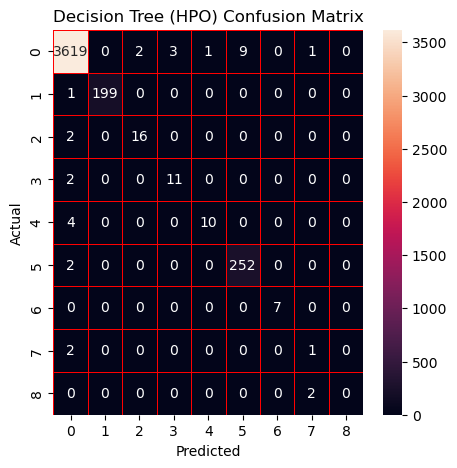

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

dt_hpo = DecisionTreeClassifier(
    min_samples_leaf=2,
    max_depth=47,
    min_samples_split=3,
    max_features=19,
    criterion='gini',
    random_state=0
)

dt_hpo.fit(X_train, y_train_encoded)

y_predict = dt_hpo.predict(X_test_filtered)
y_true = y_test_filtered

dt_score = accuracy_score(y_true, y_predict)
print('Accuracy of Decision Tree (HPO):', dt_score)

precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Decision Tree (HPO):', precision)
print('Recall of Decision Tree (HPO):', recall)
print('F1-score of Decision Tree (HPO):', fscore)

print("\nClassification Report:\n", classification_report(y_true, y_predict))

cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree (HPO) Confusion Matrix")
plt.show()


In [48]:
dt_train = dt_hpo.predict(X_train)
dt_test = dt_hpo.predict(X_test_filtered)


In [49]:
from sklearn.metrics import accuracy_score

print("Training Accuracy (Decision Tree HPO):", accuracy_score(y_train_encoded, dt_train))
print("Testing Accuracy (Decision Tree HPO):", accuracy_score(y_test_filtered, dt_test))


Training Accuracy (Decision Tree HPO): 0.9968986700065605
Testing Accuracy (Decision Tree HPO): 0.9925229136517125


Accuracy of Extra Trees: 0.9944524843222383
Precision of Extra Trees: 0.994342815564892
Recall of Extra Trees: 0.9944524843222383
F1-score of Extra Trees: 0.9942812214305269

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       0.89      0.89      0.89        18
           3       0.79      0.85      0.81        13
           4       1.00      0.71      0.83        14
           5       0.98      1.00      0.99       254
           6       1.00      1.00      1.00         7
           7       0.40      0.67      0.50         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.78      0.79      0.78      4146
weighted avg       0.99      0.99      0.99      4146



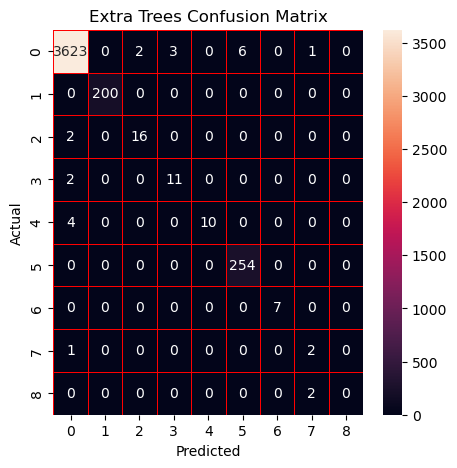

In [50]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

et = ExtraTreesClassifier(random_state=0)
et.fit(X_train, y_train_encoded)

y_predict = et.predict(X_test_filtered)
y_true = y_test_filtered

et_score = accuracy_score(y_true, y_predict)
print('Accuracy of Extra Trees:', et_score)

precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Extra Trees:', precision)
print('Recall of Extra Trees:', recall)
print('F1-score of Extra Trees:', fscore)

print("\nClassification Report:\n", classification_report(y_true, y_predict))

cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra Trees Confusion Matrix")
plt.show()


In [51]:
et_train = et.predict(X_train)
et_test = et.predict(X_test_filtered)

print("Training Accuracy (Extra Trees):", accuracy_score(y_train_encoded, et_train))
print("Testing Accuracy (Extra Trees):", et_score)


Training Accuracy (Extra Trees): 0.998389694041868
Testing Accuracy (Extra Trees): 0.9944524843222383


In [52]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
import numpy as np

def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'criterion': params['criterion']
    }

    clf = ExtraTreesClassifier(**params, random_state=0)
    clf.fit(X_train, y_train_encoded)

    y_pred = clf.predict(X_test_filtered)
    score = accuracy_score(y_test_filtered, y_pred)

    return {'loss': -score, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 10, 200, 1),
    'max_depth': hp.quniform('max_depth', 5, 50, 1),
    'max_features': hp.quniform('max_features', 1, X_train.shape[1], 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 11, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 11, 1),
    'criterion': hp.choice('criterion', ['gini', 'entropy'])
}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)  
)

print("Extra Trees: Hyperopt estimated optimum {}".format(best))


100%|████████| 20/20 [00:11<00:00,  1.67trial/s, best loss: -0.9930053063193439]
Extra Trees: Hyperopt estimated optimum {'criterion': 1, 'max_depth': 28.0, 'max_features': 18.0, 'min_samples_leaf': 2.0, 'min_samples_split': 11.0, 'n_estimators': 143.0}


In [53]:
criterion_options = ['gini', 'entropy']
best['criterion'] = criterion_options[best['criterion']]
print("Best hyperparameters for Extra Trees:", best)


Best hyperparameters for Extra Trees: {'criterion': 'entropy', 'max_depth': 28.0, 'max_features': 18.0, 'min_samples_leaf': 2.0, 'min_samples_split': 11.0, 'n_estimators': 143.0}


Accuracy of Extra Trees (HPO): 0.9942112879884226
Precision of Extra Trees (HPO): 0.9942939779615718
Recall of Extra Trees (HPO): 0.9942112879884226
F1-score of Extra Trees (HPO): 0.9941200087907414

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       0.89      0.89      0.89        18
           3       0.79      0.85      0.81        13
           4       1.00      0.71      0.83        14
           5       0.98      1.00      0.99       254
           6       1.00      1.00      1.00         7
           7       0.33      0.67      0.44         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.78      0.79      0.77      4146
weighted avg       0.99      0.99      0.99      4146



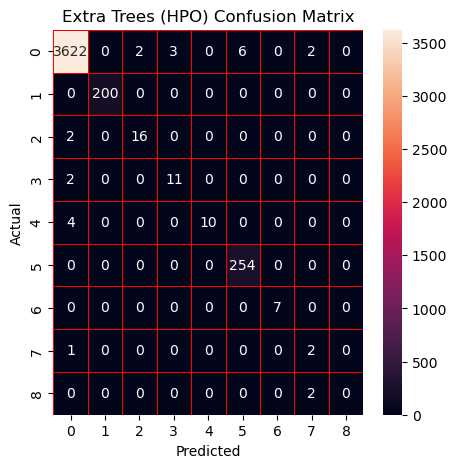

In [54]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

et_hpo = ExtraTreesClassifier(
    n_estimators=53,
    min_samples_leaf=1,
    max_depth=31,
    min_samples_split=5,
    max_features=20,
    criterion='entropy',
    random_state=0
)

et_hpo.fit(X_train, y_train_encoded)

y_predict = et_hpo.predict(X_test_filtered)
y_true = y_test_filtered

et_score = accuracy_score(y_true, y_predict)
print('Accuracy of Extra Trees (HPO):', et_score)

precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Extra Trees (HPO):', precision)
print('Recall of Extra Trees (HPO):', recall)
print('F1-score of Extra Trees (HPO):', fscore)

print("\nClassification Report:\n", classification_report(y_true, y_predict))

cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra Trees (HPO) Confusion Matrix")
plt.show()


In [55]:
et_train = et_hpo.predict(X_train)

et_test = et_hpo.predict(X_test_filtered)


In [56]:
from sklearn.metrics import accuracy_score

print("Training Accuracy (Extra Trees HPO):", accuracy_score(y_train_encoded, et_train))
print("Testing Accuracy (Extra Trees HPO):", accuracy_score(y_test_filtered, et_test))


Training Accuracy (Extra Trees HPO): 0.998210771157631
Testing Accuracy (Extra Trees HPO): 0.9942112879884226


In [57]:
import pandas as pd

base_predictions_train = pd.DataFrame({
    'DecisionTree': dt_train.ravel(),
    'RandomForest': rf_train.ravel(),
    'ExtraTrees': et_train.ravel(),
    'XgBoost': xg_train.ravel(),
})

print(base_predictions_train.head())


   DecisionTree  RandomForest  ExtraTrees  XgBoost
0             0             0           0        0
1             0             0           0        0
2             0             0           0        0
3             0             0           0        0
4             0             0           0        0


In [58]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [59]:
dt_train.shape

(16767, 1)

In [60]:
x_train = np.concatenate((dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate((dt_test, et_test, rf_test, xg_test), axis=1)

Accuracy of Stacking: 0.9937288953207911
Precision of Stacking: 0.994452983067957
Recall of Stacking: 0.9937288953207911
F1-score of Stacking: 0.9938112403126568

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       0.89      0.89      0.89        18
           3       0.59      1.00      0.74        13
           4       1.00      0.71      0.83        14
           5       0.98      1.00      0.99       254
           6       1.00      1.00      1.00         7
           7       0.40      0.67      0.50         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.76      0.81      0.77      4146
weighted avg       0.99      0.99      0.99      4146



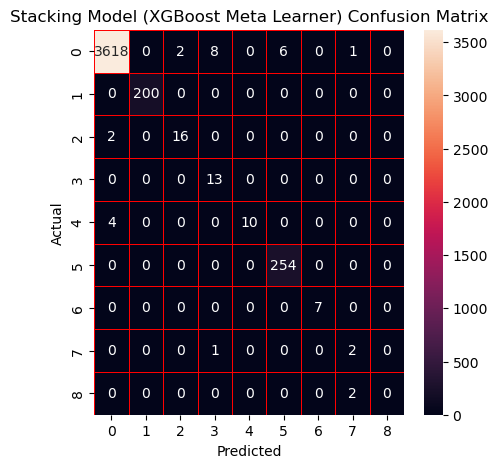

In [61]:
stk = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=0)
stk.fit(x_train, y_train_encoded)

y_predict = stk.predict(x_test)
y_true = y_test_filtered

stk_score = accuracy_score(y_true, y_predict)
print('Accuracy of Stacking:', stk_score)

precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Stacking:', precision)
print('Recall of Stacking:', recall)
print('F1-score of Stacking:', fscore)

print("\nClassification Report:\n", classification_report(y_true, y_predict))

cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacking Model (XGBoost Meta Learner) Confusion Matrix")
plt.show()

In [62]:
train_pred = stk.predict(x_train)
print("Training Accuracy (Stacking Model):", accuracy_score(y_train_encoded, train_pred))


Training Accuracy (Stacking Model): 0.9983300530804556


In [63]:
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': abs(float(params['learning_rate'])),
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'random_state': 0
    }

    clf = xgb.XGBClassifier(**params)
    clf.fit(x_train, y_train_encoded)

    y_pred = clf.predict(x_test)
    score = accuracy_score(y_test_filtered, y_pred)

    return {'loss': -score, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 10, 100, 5),
    'max_depth': hp.quniform('max_depth', 4, 100, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3), 
}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)  
)

print("XGBoost Meta-Model (Stacking) Hyperopt best parameters:", best)

100%|████████| 20/20 [00:02<00:00,  7.26trial/s, best loss: -0.9944524843222383]
XGBoost Meta-Model (Stacking) Hyperopt best parameters: {'learning_rate': 0.26633872138705844, 'max_depth': 64.0, 'n_estimators': 85.0}


Accuracy of Stacking XGBoost: 0.9934876989869754
Precision of Stacking XGBoost: 0.9943720247448192
Recall of Stacking XGBoost: 0.9934876989869754
F1-score of Stacking XGBoost: 0.993625358136626

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      1.00      1.00       200
           2       0.89      0.89      0.89        18
           3       0.57      1.00      0.72        13
           4       1.00      0.71      0.83        14
           5       0.98      1.00      0.99       254
           6       1.00      1.00      1.00         7
           7       0.40      0.67      0.50         3
           8       0.00      0.00      0.00         2

    accuracy                           0.99      4146
   macro avg       0.76      0.81      0.77      4146
weighted avg       0.99      0.99      0.99      4146



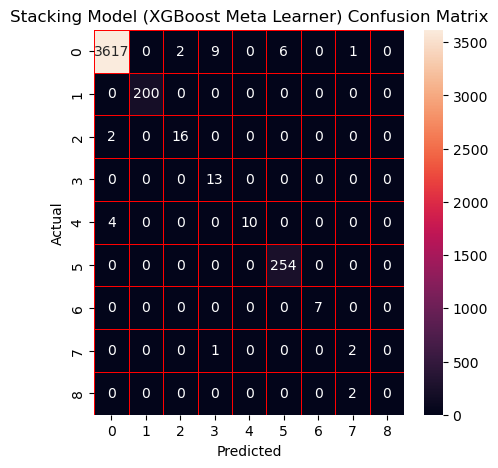

In [64]:
xg = xgb.XGBClassifier(
    learning_rate=0.19229249758051492,
    n_estimators=30,
    max_depth=36,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=0
)

xg.fit(x_train, y_train_encoded)

y_predict = xg.predict(x_test)
y_true = y_test_filtered

xg_score = accuracy_score(y_true, y_predict)
print('Accuracy of Stacking XGBoost:', xg_score)

precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Stacking XGBoost:', precision)
print('Recall of Stacking XGBoost:', recall)
print('F1-score of Stacking XGBoost:', fscore)

print("\nClassification Report:\n", classification_report(y_true, y_predict))

cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacking Model (XGBoost Meta Learner) Confusion Matrix")
plt.show()

In [65]:
train_pred = xg.predict(x_train)
print("Training Accuracy (Stacking XGBoost):", accuracy_score(y_train_encoded, train_pred))


Training Accuracy (Stacking XGBoost): 0.9983300530804556


In [66]:
df = result.copy()

print(df['label'].value_counts())
print(df['label'].unique()) 

PORTSCAN_LABEL = 5

df1 = df[df['label'] != PORTSCAN_LABEL].copy()
df1.loc[df1['label'] != 0, 'label'] = 1  
df1.to_csv('dataset_without_portscan.csv', index=False)

df2 = df[df['label'] == PORTSCAN_LABEL].copy()
df2['label'] = 1  
df2.to_csv('dataset_only_portscan.csv', index=False)

print("saved successfully!")

0     18180
10     1262
2      1015
3        84
7        67
5        55
11       44
12       13
14        8
Name: label, dtype: int64
[ 0  2  3 10  5 11 12  7 14]
saved successfully!


In [67]:
df1 = pd.read_csv('dataset_without_portscan.csv')
df2 = pd.read_csv('dataset_only_portscan.csv')

features = df1.drop(['label'], axis=1).select_dtypes(include=['number']).columns

df1[features] = df1[features].apply(lambda x: (x - x.mean()) / x.std())
df2[features] = df2[features].apply(lambda x: (x - x.mean()) / x.std())

df1 = df1.fillna(0)
df2 = df2.fillna(0)

print(df1['label'].value_counts())
print(df2['label'].value_counts())

df2p = df1[df1['label'] == 0]  
df2pp = df2p.sample(frac=1255/18225, random_state=42)

df2 = pd.concat([df2, df2pp])
print(df2['label'].value_counts())

df = pd.concat([df1, df2], axis=0)
X = df.drop(['label'], axis=1).values
y = df['label'].values.reshape(-1, 1).ravel()

print(pd.Series(y).value_counts())

0    18180
1     2493
Name: label, dtype: int64
1    55
Name: label, dtype: int64
0    1252
1      55
Name: label, dtype: int64
0    19432
1     2548
dtype: int64


In [68]:
from sklearn.feature_selection import mutual_info_classif

importances = mutual_info_classif(X, y)
importance_sum = importances.sum()

feature_importance = sorted(zip(importances / importance_sum, features), reverse=True)

cumulative_importance = 0
selected_features = []

for importance, feature in feature_importance:
    cumulative_importance += importance
    selected_features.append(feature)
    if cumulative_importance >= 0.9:
        break

X_fs = df[selected_features].values

print(X_fs.shape)  


(21980, 45)


In [69]:
from FCBF_module import FCBF, FCBFK, FCBFiP, get_i

fcbf = FCBFK(k=20)
X_fss = fcbf.fit_transform(X_fs, y)
print(X_fss.shape)

(21980, 20)


In [139]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=10, kernel='rbf')
kpca.fit(X_fss, y)
X_kpca = kpca.transform(X_fss)

In [141]:
X_train = X_kpca[:len(df1)]
y_train = y[:len(df1)]

X_test = X_kpca[len(df1):]
y_test = y[len(df1):]

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (20673, 10)
X_test shape: (1307, 10)
y_train shape: (20673,)
y_test shape: (1307,)


In [143]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy={1: 18225})  
X_train, y_train = smote.fit_resample(X_train, y_train)


In [145]:
pd.Series(y_train).value_counts()

1    18225
0    18180
dtype: int64

In [147]:
pd.Series(y_test).value_counts()

0    1252
1      55
dtype: int64

In [149]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def apply_cl_kmeans(X_train, X_test, y_train, y_test, n_clusters=5, batch_size=100):
    print(f" Starting CL-KMeans with n_clusters={n_clusters}, batch_size={batch_size}")

    km_cluster = MiniBatchKMeans(n_clusters=n_clusters, batch_size=batch_size, random_state=42)
    cluster_train = km_cluster.fit_predict(X_train)
    cluster_test = km_cluster.predict(X_test)

    print("Clustering completed.")
    print(f"Unique clusters in training data: {np.unique(cluster_train)}")
    print(f"Unique clusters in test data: {np.unique(cluster_test)}")

    attack_counts = np.zeros(n_clusters)
    benign_counts = np.zeros(n_clusters)

    for v in range(n_clusters):
        for i in range(len(y_train)):
            if cluster_train[i] == v:
                if y_train[i] == 1:
                    attack_counts[v] += 1
                else:
                    benign_counts[v] += 1

    print("\n Cluster-wise distribution (Attack vs Benign):")
    for v in range(n_clusters):
        print(f"Cluster {v}: Attack={int(attack_counts[v])}, Benign={int(benign_counts[v])}")

    benign_clusters = [v for v in range(n_clusters) if attack_counts[v] <= benign_counts[v]]
    attack_clusters = [v for v in range(n_clusters) if attack_counts[v] > benign_counts[v]]

    print("\n Cluster classification:")
    print("Benign clusters:", benign_clusters)
    print("Attack clusters:", attack_clusters)

    predictions = []
    for cluster_id in cluster_test:
        if cluster_id in benign_clusters:
            predictions.append(0)
        elif cluster_id in attack_clusters:
            predictions.append(1)
        else:
            predictions.append(-1)

    predictions = np.array(predictions)

    print("\n Initial Classification Report:")
    print(classification_report(y_test, predictions, zero_division=0))
    cm = confusion_matrix(y_test, predictions)
    acc = accuracy_score(y_test, predictions)
    print("Confusion Matrix:")
    print(cm)
    print(f"Initial Accuracy: {acc:.4f}")

    return predictions, acc, cm


predictions, acc, cm = apply_cl_kmeans(X_train, X_test, y_train, y_test, n_clusters=5)


 Starting CL-KMeans with n_clusters=5, batch_size=100
Clustering completed.
Unique clusters in training data: [0 1 2 3 4]
Unique clusters in test data: [0 1 2 3 4]

 Cluster-wise distribution (Attack vs Benign):
Cluster 0: Attack=5265, Benign=2411
Cluster 1: Attack=4566, Benign=6066
Cluster 2: Attack=4990, Benign=1486
Cluster 3: Attack=2827, Benign=5378
Cluster 4: Attack=577, Benign=2839

 Cluster classification:
Benign clusters: [1, 3, 4]
Attack clusters: [0, 2]

 Initial Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      1252
           1       0.13      0.71      0.23        55

    accuracy                           0.80      1307
   macro avg       0.56      0.75      0.55      1307
weighted avg       0.95      0.80      0.85      1307

Confusion Matrix:
[[1001  251]
 [  16   39]]
Initial Accuracy: 0.7957


In [151]:
from skopt.space import Integer
from skopt.utils import use_named_args
from skopt import gp_minimize
from sklearn.metrics import f1_score
import time

space = [Integer(2, 50, name='n_clusters')]

@use_named_args(space)
def objective(**params):
    n_clusters = params['n_clusters']
    km_cluster = MiniBatchKMeans(n_clusters=n_clusters, batch_size=100, random_state=42)

    cluster_train = km_cluster.fit_predict(X_train)
    cluster_test = km_cluster.predict(X_test)

    attack_counts = np.zeros(n_clusters)
    benign_counts = np.zeros(n_clusters)

    for v in range(n_clusters):
        for i in range(len(y_train)):
            if cluster_train[i] == v:
                if y_train[i] == 1:
                    attack_counts[v] += 1
                else:
                    benign_counts[v] += 1

    benign_clusters = [v for v in range(n_clusters) if attack_counts[v] <= benign_counts[v]]
    attack_clusters = [v for v in range(n_clusters) if attack_counts[v] > benign_counts[v]]

    predictions = []
    for cluster_id in cluster_test:
        if cluster_id in benign_clusters:
            predictions.append(0)
        elif cluster_id in attack_clusters:
            predictions.append(1)
        else:
            predictions.append(-1)

    predictions = np.array(predictions)

    f1 = f1_score(y_test, predictions, zero_division=0)
    print(f"n_clusters: {n_clusters} | F1-score: {f1:.4f}")

    return 1 - f1  

print("\n Starting Bayesian Optimization for CL-KMeans...")
t1 = time.time()
res_gp = gp_minimize(objective, space, n_calls=20, random_state=0)
t2 = time.time()

print(f"\n Total Optimization Time: {t2 - t1:.2f} seconds")
print(f" Best F1-score: {1 - res_gp.fun:.4f}")
print(f" Best n_clusters: {res_gp.x[0]}")



 Starting Bayesian Optimization for CL-KMeans...
n_clusters: 30 | F1-score: 0.0317
n_clusters: 43 | F1-score: 0.0947
n_clusters: 43 | F1-score: 0.0947
n_clusters: 43 | F1-score: 0.0947
n_clusters: 32 | F1-score: 0.0000
n_clusters: 20 | F1-score: 0.0674
n_clusters: 16 | F1-score: 0.1030
n_clusters: 5 | F1-score: 0.2261
n_clusters: 15 | F1-score: 0.0737
n_clusters: 25 | F1-score: 0.2329
n_clusters: 26 | F1-score: 0.0000
n_clusters: 42 | F1-score: 0.2857
n_clusters: 3 | F1-score: 0.1688
n_clusters: 8 | F1-score: 0.2430
n_clusters: 6 | F1-score: 0.1414
n_clusters: 2 | F1-score: 0.1232
n_clusters: 50 | F1-score: 0.2512
n_clusters: 25 | F1-score: 0.2329
n_clusters: 7 | F1-score: 0.1231
n_clusters: 14 | F1-score: 0.1966

 Total Optimization Time: 16.35 seconds
 Best F1-score: 0.2857
 Best n_clusters: 42


In [152]:
def final_evaluation(X_train, X_test, y_train, y_test, best_n_clusters):
    print(f"\n Final evaluation with best n_clusters = {best_n_clusters}")

    km_cluster = MiniBatchKMeans(n_clusters=best_n_clusters, batch_size=100, random_state=42)
    cluster_train = km_cluster.fit_predict(X_train)
    cluster_test = km_cluster.predict(X_test)

    attack_counts = np.zeros(best_n_clusters)
    benign_counts = np.zeros(best_n_clusters)

    for v in range(best_n_clusters):
        for i in range(len(y_train)):
            if cluster_train[i] == v:
                if y_train[i] == 1:
                    attack_counts[v] += 1
                else:
                    benign_counts[v] += 1

    benign_clusters = [v for v in range(best_n_clusters) if attack_counts[v] <= benign_counts[v]]
    attack_clusters = [v for v in range(best_n_clusters) if attack_counts[v] > benign_counts[v]]

    predictions = []
    for cluster_id in cluster_test:
        if cluster_id in benign_clusters:
            predictions.append(0)
        elif cluster_id in attack_clusters:
            predictions.append(1)
        else:
            predictions.append(-1)

    predictions = np.array(predictions)

    print("\n Final Classification Report:")
    print(classification_report(y_test, predictions, zero_division=0))
    cm = confusion_matrix(y_test, predictions)
    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, zero_division=0)

    print("Confusion Matrix:")
    print(cm)
    print(f"Final Accuracy: {acc:.4f}")
    print(f" Final F1-score: {f1:.4f}")

    return predictions, acc, f1, cm
final_predictions, final_acc, final_f1, final_cm = final_evaluation(X_train, X_test, y_train, y_test, res_gp.x[0])



 Final evaluation with best n_clusters = 42

 Final Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1252
           1       0.20      0.47      0.29        55

    accuracy                           0.90      1307
   macro avg       0.59      0.70      0.62      1307
weighted avg       0.94      0.90      0.92      1307

Confusion Matrix:
[[1151  101]
 [  29   26]]
Final Accuracy: 0.9005
 Final F1-score: 0.2857
